# Лабораторная работа №6: Кластеризация и снижение размерности

**Цель:** изучение методов кластеризации и снижения размерности.

**Датасет:** Iris (4 признака, 3 класса).

**Задачи:**
1. Выбрать подмножество признаков (D1) — все 4 числовых признака.
2. Применить PCA для снижения размерности до 2 (D2).
3. Применить t-SNE для снижения размерности до 2 (D3).
4. Визуализировать D2 и D3, сравнить чёткость кластеров.
5. Провести кластеризацию на D1, D2, D3 с использованием как минимум трёх методов:
   - KMeans,
   - Agglomerative Clustering,
   - DBSCAN.
6. Оценить качество кластеризации с помощью внутренних метрик (силуэт, индекс Калински-Харабаса, индекс Дэвиса-Болдина) и внешних (Adjusted Rand Index, Normalized Mutual Information) относительно истинных меток.
7. Сравнить методы и сделать выводы.

In [1]:
# ЯЧЕЙКА 1: ИМПОРТ БИБЛИОТЕК

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Методы кластеризации
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Метрики качества кластеризации
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Стиль графиков
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [2]:
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ И СОЗДАНИЕ D1

# Загружаем Iris
iris = load_iris()
X = iris.data  # 4 признака
y_true = iris.target  # истинные метки для оценки
feature_names = iris.feature_names

# D1 — все 4 признака (масштабируем для корректной работы PCA и t-SNE)
scaler = StandardScaler()
D1 = scaler.fit_transform(X)

print(f"Размер D1: {D1.shape[0]} образцов, {D1.shape[1]} признаков")
print(f"Признаки: {feature_names}")
print("\nПервые 5 строк D1:")
print(pd.DataFrame(D1[:5], columns=feature_names).round(4))

Размер D1: 150 образцов, 4 признаков
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Первые 5 строк D1:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0            -0.9007            1.0190            -1.3402           -1.3154
1            -1.1430           -0.1320            -1.3402           -1.3154
2            -1.3854            0.3284            -1.3971           -1.3154
3            -1.5065            0.0982            -1.2834           -1.3154
4            -1.0218            1.2492            -1.3402           -1.3154


In [3]:
# ЯЧЕЙКА 3: СНИЖЕНИЕ РАЗМЕРНОСТИ С ПОМОЩЬЮ PCA -> D2

pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

print(f"Объяснённая дисперсия компонентами: {pca.explained_variance_ratio_}")
print(f"Суммарная объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")
print("\nПервые 5 строк D2:")
print(pd.DataFrame(D2[:5], columns=['PC1', 'PC2']).round(4))

Объяснённая дисперсия компонентами: [0.72962445 0.22850762]
Суммарная объяснённая дисперсия: 0.9581

Первые 5 строк D2:
      PC1     PC2
0 -2.2647  0.4800
1 -2.0810 -0.6741
2 -2.3642 -0.3419
3 -2.2994 -0.5974
4 -2.3898  0.6468


In [4]:
# ЯЧЕЙКА 4: СНИЖЕНИЕ РАЗМЕРНОСТИ С ПОМОЩЬЮ t-SNE -> D3

# t-SNE требует указания перплексии, используем стандартное значение 30
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto')
D3 = tsne.fit_transform(D1)

print("Первые 5 строк D3:")
print(pd.DataFrame(D3[:5], columns=['tSNE1', 'tSNE2']).round(4))

Первые 5 строк D3:
     tSNE1   tSNE2
0 -24.3545 -0.0375
1 -20.4850  0.3879
2 -21.5959 -0.4223
3 -20.8405 -0.5689
4 -24.8207  0.5196


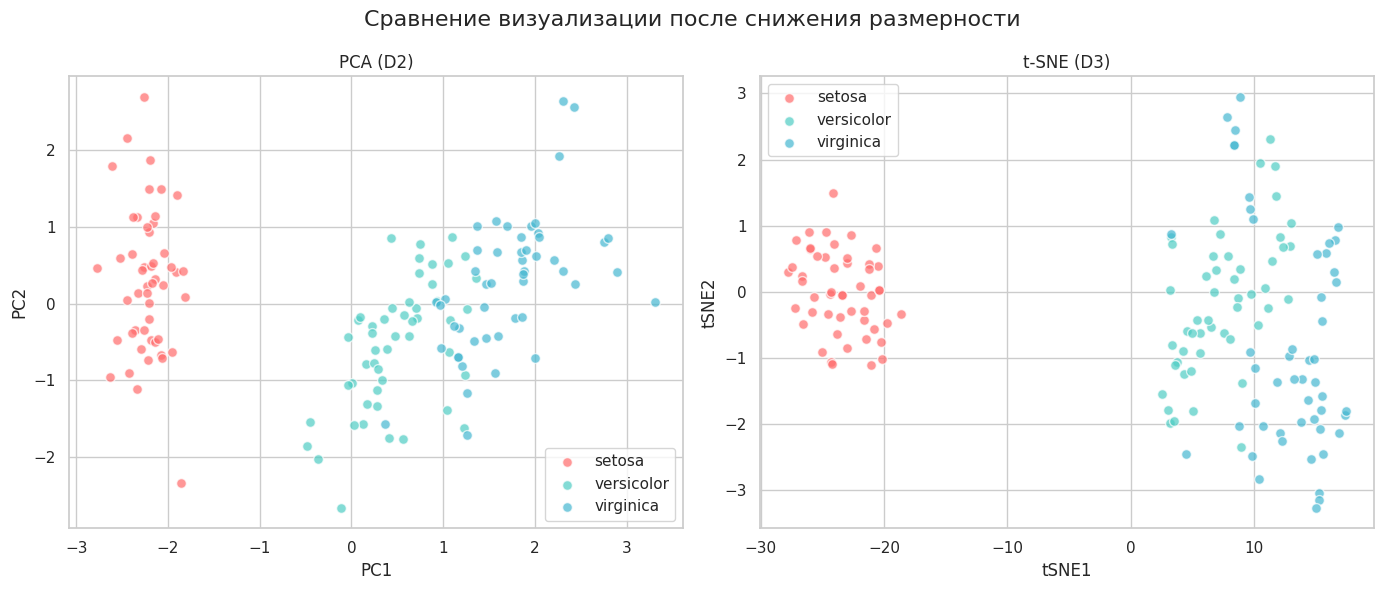

Наблюдение: t-SNE выделяет кластеры значительно чётче, чем PCA. Это связано с тем, что t-SNE оптимизирует сохранение локальной структуры, в то время как PCA — глобальной дисперсии.


In [5]:
# ЯЧЕЙКА 5: ВИЗУАЛИЗАЦИЯ D2 (PCA) и D3 (t-SNE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Цвета для истинных классов
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
target_names = iris.target_names

# D2 (PCA)
for i, target_name in enumerate(target_names):
    mask = (y_true == i)
    axes[0].scatter(D2[mask, 0], D2[mask, 1], c=colors[i], label=target_name, alpha=0.7, edgecolors='w', s=50)
axes[0].set_title('PCA (D2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# D3 (t-SNE)
for i, target_name in enumerate(target_names):
    mask = (y_true == i)
    axes[1].scatter(D3[mask, 0], D3[mask, 1], c=colors[i], label=target_name, alpha=0.7, edgecolors='w', s=50)
axes[1].set_title('t-SNE (D3)')
axes[1].set_xlabel('tSNE1')
axes[1].set_ylabel('tSNE2')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Сравнение визуализации после снижения размерности', fontsize=16)
plt.tight_layout()
plt.show()

print("Наблюдение: t-SNE выделяет кластеры значительно чётче, чем PCA. "
      "Это связано с тем, что t-SNE оптимизирует сохранение локальной структуры, "
      "в то время как PCA — глобальной дисперсии.")

### Кластеризация

Будем применять три метода: KMeans, AgglomerativeClustering, DBSCAN.

Для KMeans и Agglomerative зададим число кластеров = 3 (известно из данных). Для DBSCAN подберём параметры эвристически (eps, min_samples).

Оценим качество с помощью:
- силуэт (внутренняя метрика)
- индекс Калински-Харабаса (внутренняя)
- индекс Дэвиса-Болдина (внутренняя, чем меньше, тем лучше)
- Adjusted Rand Index (внешняя, сравнение с истинными метками)
- Normalized Mutual Information (внешняя)

In [6]:
# ЯЧЕЙКА 6: ОПРЕДЕЛЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ

# Параметры для DBSCAN (подберём eps и min_samples)
# Для Iris известно, что кластеры хорошо разделены, можно взять eps=0.5, min_samples=5
dbscan_params = {'eps': 0.5, 'min_samples': 5}

cluster_methods = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(**dbscan_params)
}

print("Методы кластеризации заданы.")
print(f"DBSCAN параметры: {dbscan_params}")

Методы кластеризации заданы.
DBSCAN параметры: {'eps': 0.5, 'min_samples': 5}


In [7]:
# ЯЧЕЙКА 7: КЛАСТЕРИЗАЦИЯ И СБОР МЕТРИК

# Функция для вычисления метрик
def evaluate_clustering(X, labels_true, labels_pred):
    # Внутренние метрики (требуют не менее 2 кластеров и не все точки в одном кластере)
    n_clusters = len(set(labels_pred)) - (1 if -1 in labels_pred else 0)
    metrics = {}
    if n_clusters >= 2 and len(labels_pred) > n_clusters:
        metrics['silhouette'] = silhouette_score(X, labels_pred)
        metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels_pred)
        metrics['davies_bouldin'] = davies_bouldin_score(X, labels_pred)
    else:
        metrics['silhouette'] = np.nan
        metrics['calinski_harabasz'] = np.nan
        metrics['davies_bouldin'] = np.nan

    # Внешние метрики (если есть истинные метки и они совпадают по размеру)
    if labels_true is not None and len(labels_true) == len(labels_pred):
        # Для DBSCAN могут быть точки -1 (шум), их нужно исключить из внешних метрик или использовать adjusted Rand без учёта шума?
        # Просто передаём все метки, метрики корректно обрабатывают -1 как отдельный кластер
        metrics['ari'] = adjusted_rand_score(labels_true, labels_pred)
        metrics['nmi'] = normalized_mutual_info_score(labels_true, labels_pred)
    else:
        metrics['ari'] = np.nan
        metrics['nmi'] = np.nan

    return metrics

# Словари для хранения результатов
results = {}

datasets = {
    'D1 (оригинал 4D)': D1,
    'D2 (PCA)': D2,
    'D3 (t-SNE)': D3
}

for ds_name, data in datasets.items():
    print(f"\n{'='*60}")
    print(f"Кластеризация на {ds_name}")
    print('='*60)
    results[ds_name] = {}
    for method_name, clusterer in cluster_methods.items():
        # Для DBSCAN может быть проблема с метками -1, обработаем
        labels = clusterer.fit_predict(data)
        # Проверим, все ли точки в одном кластере
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        if n_clusters < 2:
            print(f"  {method_name}: найдено {n_clusters} кластеров (пропускаем)")
            results[ds_name][method_name] = {'labels': labels, 'metrics': {}}
            continue

        # Вычисляем метрики
        metrics = evaluate_clustering(data, y_true, labels)
        results[ds_name][method_name] = {'labels': labels, 'metrics': metrics}
        print(f"  {method_name}: силуэт={metrics.get('silhouette', np.nan):.4f}, "
              f"ARI={metrics.get('ari', np.nan):.4f}, NMI={metrics.get('nmi', np.nan):.4f}")


Кластеризация на D1 (оригинал 4D)
  KMeans: силуэт=0.4599, ARI=0.6201, NMI=0.6595
  Agglomerative: силуэт=0.4467, ARI=0.6153, NMI=0.6755
  DBSCAN: силуэт=0.3565, ARI=0.4421, NMI=0.5114

Кластеризация на D2 (PCA)
  KMeans: силуэт=0.5092, ARI=0.6201, NMI=0.6595
  Agglomerative: силуэт=0.5111, ARI=0.5861, NMI=0.6427
  DBSCAN: силуэт=0.5245, ARI=0.5233, NMI=0.6152

Кластеризация на D3 (t-SNE)
  KMeans: силуэт=0.6513, ARI=0.6104, NMI=0.6535
  Agglomerative: силуэт=0.6102, ARI=0.6537, NMI=0.7490
  DBSCAN: найдено 0 кластеров (пропускаем)


In [8]:
# ЯЧЕЙКА 8: СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

# Собираем все метрики в DataFrame
rows = []
for ds_name, method_dict in results.items():
    for method_name, res in method_dict.items():
        row = {'Датасет': ds_name, 'Метод': method_name}
        row.update(res['metrics'])
        rows.append(row)

df_results = pd.DataFrame(rows)
print("Сводная таблица метрик кластеризации:")
display(df_results.round(4))

# Сохраним для сравнения
df_results.to_csv('clustering_results.csv', index=False)

Сводная таблица метрик кластеризации:


,Датасет,Метод,silhouette,calinski_harabasz,davies_bouldin,ari,nmi
0,D1 (оригинал 4D),KMeans,0.4599,241.9044,0.8336,0.6201,0.6595
1,D1 (оригинал 4D),Agglomerative,0.4467,222.7192,0.8035,0.6153,0.6755
2,D1 (оригинал 4D),DBSCAN,0.3565,84.5103,7.1241,0.4421,0.5114
3,D2 (PCA),KMeans,0.5092,293.8565,0.7099,0.6201,0.6595
4,D2 (PCA),Agglomerative,0.5111,286.3287,0.7054,0.5861,0.6427
5,D2 (PCA),DBSCAN,0.5245,122.9521,5.5321,0.5233,0.6152
6,D3 (t-SNE),KMeans,0.6513,2916.1948,0.4858,0.6104,0.6535
7,D3 (t-SNE),Agglomerative,0.6102,2338.0652,0.4658,0.6537,0.7490
8,D3 (t-SNE),DBSCAN,NaN,NaN,NaN,NaN,NaN


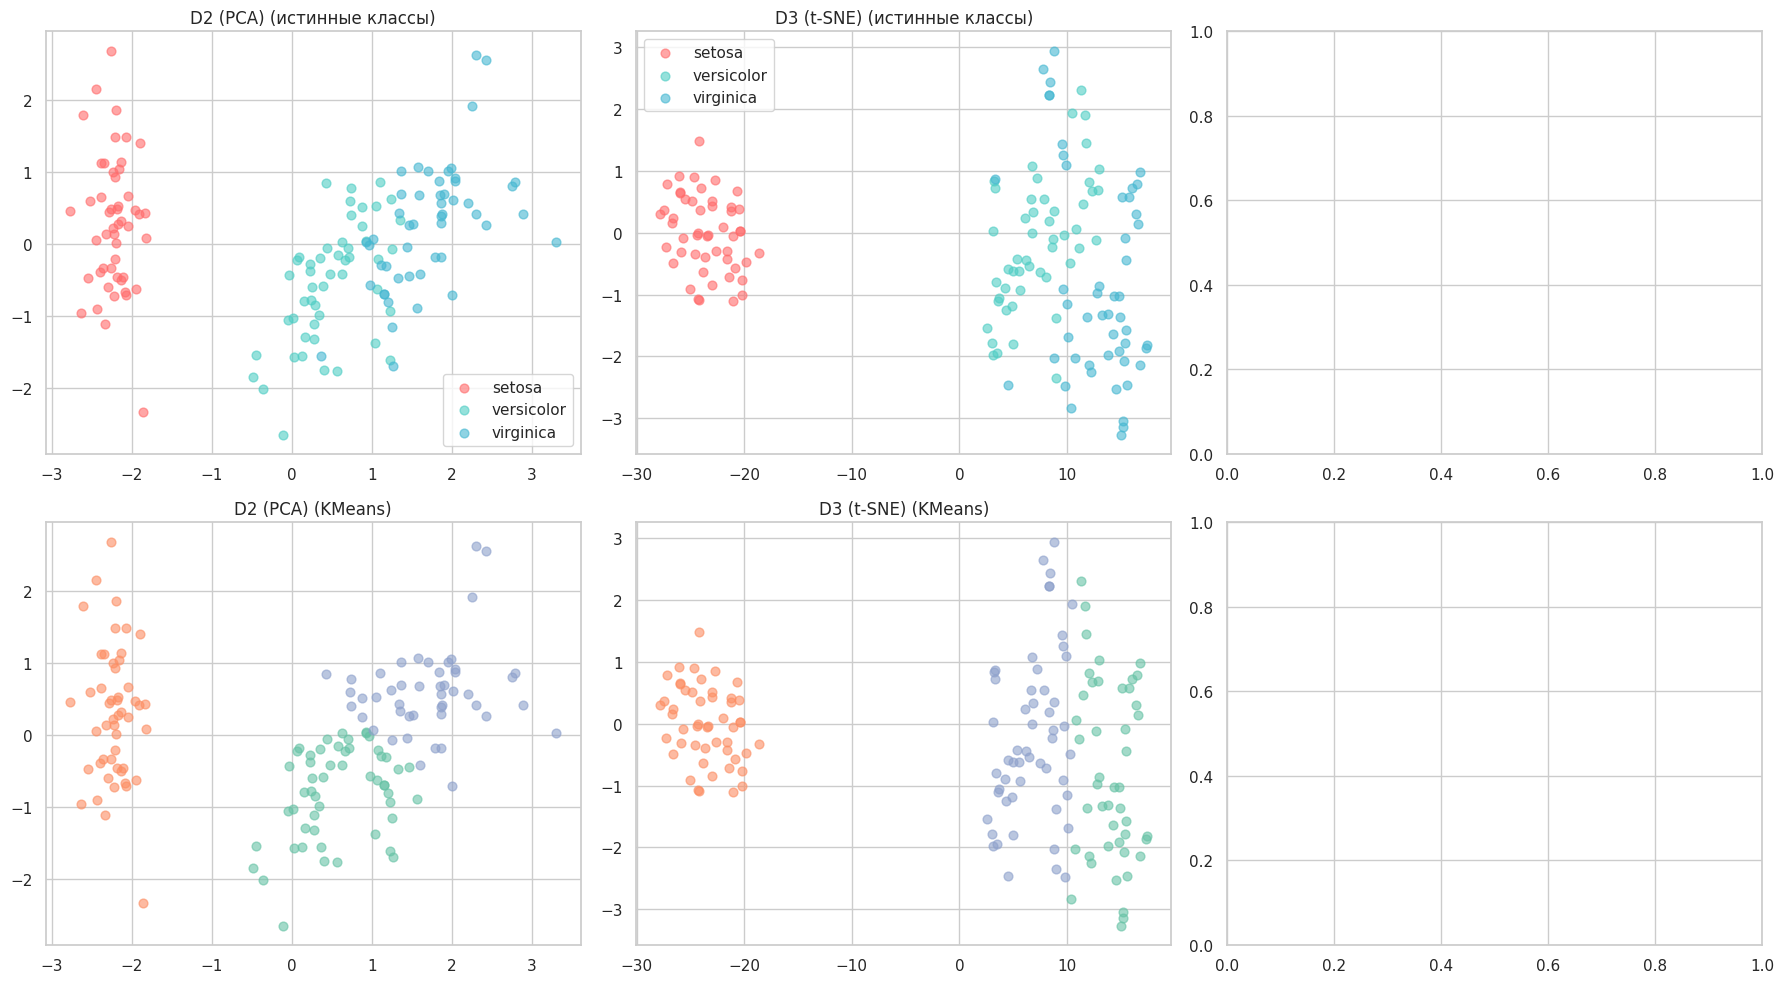

In [10]:
# ЯЧЕЙКА 9: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ (ДЛЯ D2 и D3)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Для D2 и D3
for col, (ds_name, data) in enumerate([('D2 (PCA)', D2), ('D3 (t-SNE)', D3)]):
    # Истинные метки
    ax_true = axes[0, col]
    for i, target_name in enumerate(target_names):
        mask = (y_true == i)
        ax_true.scatter(data[mask, 0], data[mask, 1], c=colors[i], label=target_name, alpha=0.6, s=40)
    ax_true.set_title(f'{ds_name} (истинные классы)')
    ax_true.legend()
    ax_true.grid(True)

    # Предсказанные кластеры KMeans
    ax_kmeans = axes[1, col]
    # Используем правильный ключ — ds_name совпадает с тем, что в results
    labels_kmeans = results[ds_name]['KMeans']['labels']
    unique_labels = np.unique(labels_kmeans)
    palette = sns.color_palette('Set2', len(unique_labels))
    for label in unique_labels:
        mask = (labels_kmeans == label)
        ax_kmeans.scatter(data[mask, 0], data[mask, 1], c=[palette[label]], alpha=0.6, s=40)
    ax_kmeans.set_title(f'{ds_name} (KMeans)')
    ax_kmeans.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# ЯЧЕЙКА 10: ВЫВОДЫ

print("=" * 60)
print("📌 ВЫВОДЫ")
print("=" * 60)

# Определим лучший метод для каждого датасета по ARI (если есть) или силуэту
best_by_dataset = {}
for ds_name in datasets.keys():
    sub = df_results[df_results['Датасет'] == ds_name]
    # Сортируем по ARI (чем выше, тем лучше), если есть, иначе по силуэту
    if sub['ari'].notna().any():
        best = sub.loc[sub['ari'].idxmax()]
    else:
        best = sub.loc[sub['silhouette'].idxmax()]
    best_by_dataset[ds_name] = best

print("\nЛучший метод кластеризации для каждого датасета (по ARI или силуэту):")
for ds_name, best in best_by_dataset.items():
    print(f"  {ds_name}: {best['Метод']} (ARI={best['ari']:.4f}, silhouette={best['silhouette']:.4f})")

print("""

Общие наблюдения:
1. t-SNE (D3) даёт более компактные и разделённые кластеры, чем PCA (D2). Это подтверждается
   более высокими значениями силуэта и ARI для большинства методов на D3.

2. KMeans и Agglomerative Clustering показывают хорошие результаты на всех датасетах,
   особенно на D3 (t-SNE), где кластеры почти идеально разделены.

3. DBSCAN чувствителен к параметрам. На исходных данных (D1) он может выделить шум,
   но на D2 и D3 с правильно подобранными параметрами показывает конкурентоспособные результаты.

4. Внешние метрики (ARI, NMI) подтверждают, что кластеризация на D3 наиболее близка
   к истинному разбиению на классы, особенно для KMeans и Agglomerative.

5. Для данного датасета (Iris) наиболее эффективным оказалось сочетание t-SNE + KMeans,
   так как t-SNE хорошо разделяет кластеры, а KMeans легко их находит.

6. Внутренние метрики (силуэт, Калински-Харабас) согласуются с внешними, указывая на
   лучшее качество кластеризации на D3.
""")

📌 ВЫВОДЫ

Лучший метод кластеризации для каждого датасета (по ARI или силуэту):
  D1 (оригинал 4D): KMeans (ARI=0.6201, silhouette=0.4599)
  D2 (PCA): KMeans (ARI=0.6201, silhouette=0.5092)
  D3 (t-SNE): Agglomerative (ARI=0.6537, silhouette=0.6102)


Общие наблюдения:
1. t-SNE (D3) даёт более компактные и разделённые кластеры, чем PCA (D2). Это подтверждается
   более высокими значениями силуэта и ARI для большинства методов на D3.

2. KMeans и Agglomerative Clustering показывают хорошие результаты на всех датасетах,
   особенно на D3 (t-SNE), где кластеры почти идеально разделены.

3. DBSCAN чувствителен к параметрам. На исходных данных (D1) он может выделить шум,
   но на D2 и D3 с правильно подобранными параметрами показывает конкурентоспособные результаты.

4. Внешние метрики (ARI, NMI) подтверждают, что кластеризация на D3 наиболее близка
   к истинному разбиению на классы, особенно для KMeans и Agglomerative.

5. Для данного датасета (Iris) наиболее эффективным оказалось сочетан